# 09 · Primera comparación: Base + LSTM frente a B + LSTM, sólo CCA

**Pregunta:** ¿añadir la distribución B reduce los cambios de banda por lectura que escapan al mismo detector?

Este notebook cierra la comparación de CCA bajo el escenario del experimento 08: 5 % de selección por lectura, N uniforme entre 1 y 16 y posiciones uniformes sin reemplazo. N es el número de bits distintos invertidos en un mensaje. Se reutilizan las mismas 100 campañas, sin crear otras ni elegir una semilla favorable.

Se usan las **predicciones y el p95 guardados de CCA del notebook 09 de la carpeta principal**, sin entrenamiento ni inferencia nueva. Este notebook 09 de `experiments/cayenne_mod/` es un documento diferente.

Base es el control binario de dominio 0…255 con posiciones 8…15 reservadas. B utiliza posiciones 0…11 y reserva 12…15. No comparamos contra un Analog Input estándar sin restricción de rango. Esta definición de Base influye en los rechazos.

## 1. Qué mantenemos igual y cómo juzgamos el resultado

| Igual en ambas opciones | Diferencia experimental |
|---|---|
| Lecturas y momentos de CCA | Representación binaria o distribución B |
| Lecturas elegidas para atacar | Interpretación del peso de cada posición |
| N y posiciones físicas invertidas | Qué posiciones están reservadas |
| Predicción y umbral del LSTM | Valor que recibe el detector, o rechazo |

**Resultado principal:** cantidad de lecturas aceptadas que cambian de banda y no generan alerta, considerando **todos los intentos**. Un rechazo se registra aparte como pérdida de dato, no como lectura conservada correctamente.

**Costos acompañantes:** falsas alarmas en lecturas limpias y rechazos. No convertimos esas medidas en un único puntaje con pesos arbitrarios.

**Diagnóstico:** también examinamos los mismos ataques aceptados por ambos formatos para separar el efecto de la distribución del efecto de aceptar más máscaras. El grupo se define por las posiciones y las reglas del formato, no por si el ataque tuvo éxito. No sustituye la comparación global ni representa a todos los atacantes.

Las alertas no retiran automáticamente lecturas. Las predicciones permanecen fijas; no se simula propagación a ventanas futuras.

In [1]:
from pathlib import Path
import sys, importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
actual=Path.cwd().resolve()
RAIZ=next(p for p in (actual,*actual.parents) if (p/'experiments/cayenne_mod/comparacion_base_B.py').is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0,str(RAIZ))
from experiments.cayenne_mod import comparacion_base_B
comparacion_base_B=importlib.reload(comparacion_base_B)
r,info=comparacion_base_B.construir(RAIZ)
r2,info2=comparacion_base_B.construir(RAIZ)
assert info==info2
for nombre in r:
    pd.testing.assert_frame_equal(r[nombre],r2[nombre],check_exact=True)
del r2
info['reproducibilidad']='Dos ejecuciones idénticas de la comparación; reutiliza las 100 campañas del 08'
DESTINO=comparacion_base_B.guardar(RAIZ,r,info)
print('Predicciones y p95 GUARDADOS; sin entrenamiento ni inferencia nueva.')
print(f"CCA: {info['n_mensajes']} lecturas, {info['n_dias']} días; umbral {info['umbral_ppb']:.6f} ppb.")
print('Los 22.6 ppb del piloto anterior corresponden a otra referencia.')
print('Pareado verificado, alertas y bandas recalculadas, conteos del 08 reproducidos.')
print('Dos ejecuciones de esta comparación idénticas. Archivos en',DESTINO.relative_to(RAIZ))

Predicciones y p95 GUARDADOS; sin entrenamiento ni inferencia nueva.
CCA: 1684 lecturas, 72 días; umbral 14.748355 ppb.
Los 22.6 ppb del piloto anterior corresponden a otra referencia.
Pareado verificado, alertas y bandas recalculadas, conteos del 08 reproducidos.
Dos ejecuciones de esta comparación idénticas. Archivos en experiments/cayenne_mod/resultados/09


## 2. Resultado principal: todos los ataques

La tabla suma las 100 campañas. Cada una vuelve a partir de las mismas 1 684 lecturas de CCA, con otro sorteo. Por eso no son 100 conjuntos independientes de contaminación.

«Detectados» se refiere a valores numéricos alterados; una alarma que ya existía en una lectura cuyo valor quedó intacto no se acredita como detección de una alteración.

In [2]:
cols={'formato':'Formato','intentos':'Intentos','rechazos':'Lecturas perdidas',
      'aceptados_atacados':'Ataques aceptados','cancelaciones':'Valor intacto',
      'alterados':'Valores alterados','detectados_alterados':'Alterados con alerta',
      'banda_local_cambiada':'Cambian banda local','banda_local_sin_alerta':'Cambian banda sin alerta'}
t=r['resumen'].query("grupo == 'todos'")
display(t[list(cols)].rename(columns=cols).reset_index(drop=True))
display(Markdown('**Conteos, no promedios:** los 13 escapes de Base y 19 de B pertenecen a las 100 campañas completas. No observamos una reducción global del daño sin alerta con B bajo este escenario. Tampoco basta este conteo pequeño para afirmar superioridad estadística de Base.'))

,Formato,Intentos,Lecturas perdidas,Ataques aceptados,Valor intacto,Valores alterados,Alterados con alerta,Cambian banda local,Cambian banda sin alerta
0,base,8377,7957,420,0,420,279,210,13
1,B,8377,7166,1211,29,1182,772,574,19


**Conteos, no promedios:** los 13 escapes de Base y 19 de B pertenecen a las 100 campañas completas. No observamos una reducción global del daño sin alerta con B bajo este escenario. Tampoco basta este conteo pequeño para afirmar superioridad estadística de Base.

## 3. Separar las dos cosas que cambia B

De los 8 377 intentos pareados:

| Grupo | Intentos | Qué significa |
|---|---:|---|
| Ambos aceptan | 420 | Podemos comparar el valor recibido con el mismo intento físico |
| Sólo B acepta | 791 | Base pierde la lectura; B permite evaluar el contenido modificado |
| Ambos rechazan | 7 166 | Los dos pierden la lectura; no hay evaluación LSTM |
| Sólo Base acepta | 0 | No ocurre: sus posiciones activas son un subconjunto de las de B |

La reducción en un subgrupo no basta si los ataques adicionales aceptados producen otros escapes. Tampoco podemos presentar los rechazos de Base como datos correctos.

In [3]:
cols={'grupo':'Grupo','formato':'Formato','intentos':'Intentos',
      'rechazos':'Rechazos','banda_local_cambiada':'Cambian banda local',
      'banda_local_sin_alerta':'Cambian banda sin alerta'}
display(r['resumen'].query("grupo in ['ambos_aceptan','solo_B_acepta']")[list(cols)]
        .rename(columns=cols).reset_index(drop=True))
print('Descomposición de B: 6 escapes en el grupo común + 13 en ataques que sólo B acepta = 19.')
print('Base: 13 escapes en el grupo común; los otros 791 intentos se rechazan y se cuentan como pérdidas.')

,Grupo,Formato,Intentos,Rechazos,Cambian banda local,Cambian banda sin alerta
0,ambos_aceptan,base,420,0,210,13
1,ambos_aceptan,B,420,0,199,6
2,solo_B_acepta,base,791,791,0,0
3,solo_B_acepta,B,791,0,375,13


Descomposición de B: 6 escapes en el grupo común + 13 en ataques que sólo B acepta = 19.
Base: 13 escapes en el grupo común; los otros 791 intentos se rechazan y se cuentan como pérdidas.


## 4. ¿Dónde aparece la complementariedad?

En los mismos 420 intentos aceptados por ambos:

- Base tiene 13 cambios de banda sin alerta.
- B tiene 6.
- De los 13 escapes de Base, 5 siguen escapando en B y 8 dejan de escapar.
- B también introduce 1 escape que Base no tenía: 5 + 1 = 6.

Eso permite identificar qué aporta la distribución y qué aporta el detector **en estos casos concretos**, sin presuponer que el cambio neto siempre disminuye.

In [4]:
display(r['explicacion_comun'])
cols={'formato':'Formato','delta_abs_medio_aceptados':'Cambio absoluto medio (ppb)',
      'recall_alterados_pct':'Valores alterados con alerta (%)',
      'banda_local_sin_alerta':'Cambian banda sin alerta'}
display(r['resumen'].query("grupo == 'ambos_aceptan'")[list(cols)]
        .rename(columns=cols).round(3).reset_index(drop=True))

,resultado,casos
0,Base escapaba; B ya no cambia banda local,4
1,Base escapaba; B cambia banda pero alerta,4
2,B crea un escape que Base no tenía,1
3,El cambio de banda escapa en ambos,5


,Formato,Cambio absoluto medio (ppb),Valores alterados con alerta (%),Cambian banda sin alerta
0,base,52.302,66.429,13
1,B,47.564,58.852,6


Aquí B evita cuatro escapes porque el valor ya no cambia de banda, y otros cuatro porque la lectura alterada sí genera alerta. También crea un escape nuevo. La tasa de detección entre valores alterados puede bajar y aun así disminuir el daño no detectado dentro de este grupo.

Con varios flips, reducir el peso de una contribución **no garantiza reducir el cambio neto de cada ataque**: también puede disminuir una contribución que antes compensaba a otra. Por eso medimos el resultado recibido y no sólo el número de bits.

## 5. Ejemplos auditables, uno por tipo de resultado

Se muestra el primer caso de cada categoría para explicar el mecanismo. Son ejemplos seleccionados por resultado, no una muestra representativa para estimar frecuencias. `NA` sigue significando rechazo y evaluación LSTM indefinida.

La predicción y el umbral son idénticos entre formatos para cada fila. Se muestran los residuos realmente calculados por el modelo experimental.

In [5]:
e=r['ejemplos'].copy()
e['bits']=e.mascara.map(lambda m: ','.join(str(b) for b in range(16) if (int(m)>>b)&1))
cols=['ejemplo','semilla','timestamp','original_ppb','n_flips','bits',
      'recibido_ppb_base','recibido_ppb_B','residuo_ppb_base','residuo_ppb_B','umbral_ppb','alerta_base','alerta_B']
vista=e[cols].copy()
numericas=vista.select_dtypes(include='number').columns
vista[numericas]=vista[numericas].round(3)
display(vista)

,ejemplo,semilla,timestamp,original_ppb,n_flips,bits,recibido_ppb_base,recibido_ppb_B,residuo_ppb_base,residuo_ppb_B,umbral_ppb,alerta_base,alerta_B
0,Base escapaba; B ya no cambia banda,63,2025-12-01 12:00:00,84.0,3,"1,4,5",102.0,86.0,3.935,12.065,14.748,False,False
1,Base escapaba; B cambia banda pero alerta,58,2025-11-10 16:00:00,20.0,2,"4,6",68.0,76.0,12.232,20.232,14.748,False,True
2,B crea un escape; ambos aceptan,123,2025-11-13 14:00:00,88.0,1,5,120.0,96.0,20.690,3.310,14.748,True,False
3,B acepta y hay escape; Base rechaza,52,2025-11-19 15:00:00,84.0,1,10,NaN,92.0,NaN,4.693,14.748,<NA>,False
4,El cambio de banda escapa en ambos,49,2025-10-25 17:00:00,88.0,1,2,92.0,92.0,12.342,12.342,14.748,False,False


## 6. Costos y variación entre campañas

Las falsas alarmas sobre lecturas no atacadas deben ser idénticas porque el detector, la lectura y los momentos de ataque son los mismos. Cambiar el formato no soluciona esas alarmas.

Los rechazos son pérdida de observaciones. Los días con banda distinta se informan por separado: **no significan días de daño sin alerta**. Las alertas registradas no eliminan lecturas en este protocolo.

In [6]:
costos=r['costos_por_semilla']
cols={'falsas_alarmas_limpios':'Falsas alarmas en limpios',
      'rechazos':'Lecturas perdidas','dias_cambio_banda_disponibles':'Días con banda distinta',
      'dias_cambio_banda_solo_perdidas':'Días con banda distinta por sólo pérdidas'}
display(costos.groupby('formato')[list(cols)].mean().rename(columns=cols).round(2))
print('Promedios por campaña. Los días se calculan sobre CCA y todos los ataques de cada día juntos.')
print(f"Sin ataques, la referencia guardada de CCA tiene {info['fpr_limpio_pct']:.2f}% de falsas alarmas.")
s=r['por_semilla'].diferencia_escapes_B_menos_base
print(f"B tiene menos escapes en {(s<0).sum()} campañas, empata en {(s==0).sum()} y tiene más en {(s>0).sum()}.")
print('Las semillas miden variación del sorteo en el mismo periodo; no prueban generalización a otro año.')

,Falsas alarmas en limpios,Lecturas perdidas,Días con banda distinta,Días con banda distinta por sólo pérdidas
formato,,,,
B,341.74,71.66,3.66,0.26
base,341.74,79.57,1.33,0.29


Promedios por campaña. Los días se calculan sobre CCA y todos los ataques de cada día juntos.
Sin ataques, la referencia guardada de CCA tiene 21.38% de falsas alarmas.
B tiene menos escapes en 8 campañas, empata en 81 y tiene más en 11.
Las semillas miden variación del sorteo en el mismo periodo; no prueban generalización a otro año.


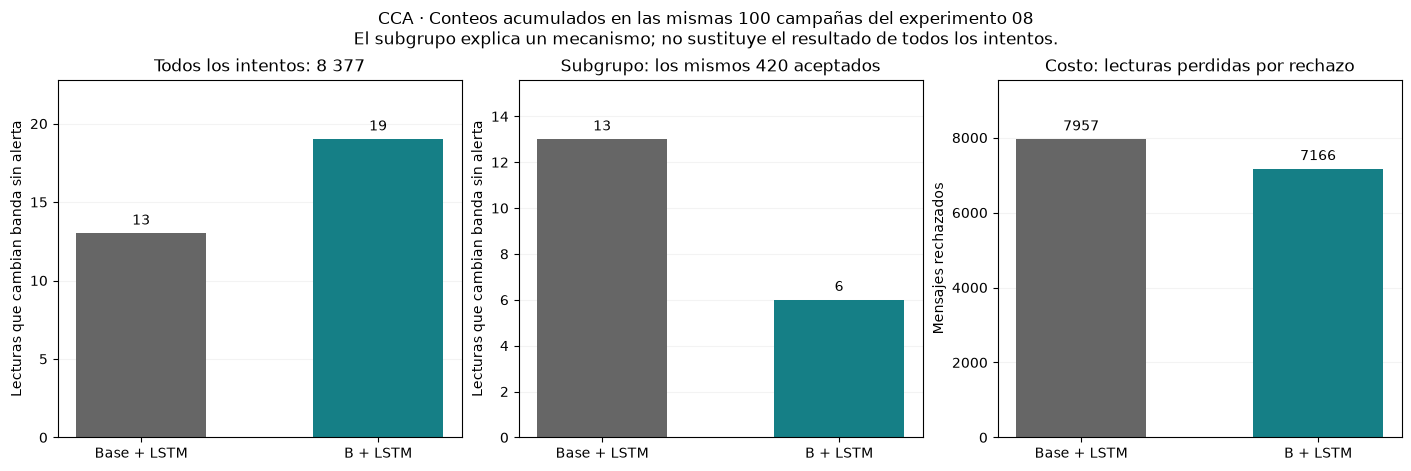

In [7]:
comparacion_base_B.graficar(r,info,DESTINO)
plt.show()

## 7. Dictamen del primer punto y pasos pendientes

**B muestra un beneficio condicionado, pero no una mejora global bajo las campañas uniformes de 1…16 flips.**

- En el grupo de aceptación común, los escapes bajan de 13 a 6. Hay ejemplos concretos de mitigación del cambio de banda y de detección del daño restante.
- Al permitir posiciones adicionales, B acepta 791 intentos que Base rechaza; 13 producen cambios de banda sin alerta. El resultado global termina en 19 frente a 13.
- B pierde 791 lecturas menos por rechazo en las 100 campañas. Algunas de esas lecturas están alteradas: menor pérdida no equivale a mayor integridad.
- Las falsas alarmas sobre datos no atacados permanecen iguales. La distribución no corrige este costo del detector.
- Con pocos escapes y el mismo periodo reutilizado, no se declara superioridad estadística ni validez general.

Este análisis responde al **primer punto para CCA bajo el protocolo actual**. No cambiamos el modelo ni el umbral para buscar una conclusión favorable.

Los siguientes puntos siguen abiertos: (2) evaluar separadamente lectura, máximo diario y cruces de 155; (3) disponer de excedencias originales suficientes para evaluar ocultamiento —el máximo limpio aquí es 145—; (4) validar en otras estaciones y otro periodo. La propagación a futuras ventanas y la relevancia de las estaciones de entrada requieren sus propios experimentos.

Los conteos completos, pares y ejemplos quedan en `resultados/09/`. El resultado de todos los intentos siempre acompaña al diagnóstico del subgrupo común.

[Resumen para la junta](avance_junta_09.md).